In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

llm =ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2)

class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content
    return {'joke': response}

def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content
    return {'explanation': response}

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)



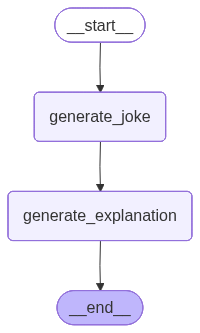

In [ ]:
workflow

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. However, in the context of a pizza, "crusty" also refers to the crunchy, outer layer of the pizza, known as the crust.\n\nThe joke relies on this dual meaning to create a humorous connection between the setup ("Why was the pizza in a bad mood?") and the punchline ("Because it was feeling a little crusty"). The wordplay on "crusty" creates a clever and amusing link between the pizza\'s emotional state and its physical characteristics, making for a lighthearted and amusing joke.'}

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. However, in the context of a pizza, "crusty" also refers to the crunchy, outer layer of the pizza, known as the crust.\n\nThe joke relies on this dual meaning to create a humorous connection between the setup ("Why was the pizza in a bad mood?") and the punchline ("Because it was feeling a little crusty"). The wordplay on "crusty" creates a clever and amusing link between the pizza\'s emotional state and its physical characteristics, making for a lighthearted and amusing joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns'

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. However, in the context of a pizza, "crusty" also refers to the crunchy, outer layer of the pizza, known as the crust.\n\nThe joke relies on this dual meaning to create a humorous connection between the setup ("Why was the pizza in a bad mood?") and the punchline ("Because it was feeling a little crusty"). The wordplay on "crusty" creates a clever and amusing link between the pizza\'s emotional state and its physical characteristics, making for a lighthearted and amusing joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'A clever play on words. This joke is funny because it uses a common phrase associated with romantic relationships, "tangled up," and gives it a literal twist. In this case, the spaghetti is afraid of getting "tangled up" because, as a long, thin, and flexible food item, it can easily become knotted or entwined with other things - including, metaphorically, its partner in a relationship.\n\nThe humor comes from the double meaning of "tangled up." In relationships, being "tangled up" usually means being deeply emotionally involved or complicatedly connected with someone. But for spaghetti, "tangled up" is a literal concern, as it can easily become physically knotted or twisted. The joke relies on this wordplay to create a humorous connection between the setup (the spaghetti refusing to get married) and the punchline (the fear of ge

In [ ]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A clever play on words. This joke is funny because it uses a common phrase associated with romantic relationships, "tangled up," and gives it a literal twist. In this case, the spaghetti is afraid of getting "tangled up" because, as a long, thin, and flexible food item, it can easily become knotted or entwined with other things - including, metaphorically, its partner in a relationship.\n\nThe humor comes from the double meaning of "tangled up." In relationships, being "tangled up" usually means being deeply emotionally involved or complicatedly connected with someone. But for spaghetti, "tangled up" is a literal concern, as it can easily become physically knotted or twisted. The joke relies on this wordplay to create a humorous connection between the setup (the spaghetti refusing to get married) and the punchl

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A clever play on words. This joke is funny because it uses a common phrase associated with romantic relationships, "tangled up," and gives it a literal twist. In this case, the spaghetti is afraid of getting "tangled up" because, as a long, thin, and flexible food item, it can easily become knotted or entwined with other things - including, metaphorically, its partner in a relationship.\n\nThe humor comes from the double meaning of "tangled up." In relationships, being "tangled up" usually means being deeply emotionally involved or complicatedly connected with someone. But for spaghetti, "tangled up" is a literal concern, as it can easily become physically knotted or twisted. The joke relies on this wordplay to create a humorous connection between the setup (the spaghetti refusing to get married) and the punch

Time Travel


In [ ]:
#accessing a state info of a particular node from thr workflow using checkpoint_id and thread concept....
workflow.get_state({"configurable":{"thread_id":"1","checkpoint_id":"1f0e2428-756e-6098-8001-3a4568ca76d5"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0e2428-756e-6098-8001-3a4568ca76d5'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-12-26T10:06:21.482204+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e2428-6e3b-6b23-8000-431afdb001cd'}}, tasks=(PregelTask(id='2664708a-ab73-9a73-0167-fb9ad273b7ae', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. 

In [ ]:
#resuming our workflow from gen_explanation node of workflow
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f0e2428-756e-6098-8001-3a4568ca76d5"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. However, in the context of a pizza, "crusty" also refers to the crunchy, outer layer of the pizza, known as the crust.\n\nThe joke relies on this dual meaning to create a humorous connection between the setup ("Why was the pizza in a bad mood?") and the punchline ("Because it was feeling a little crusty"). The wordplay on "crusty" creates a clever and amusing link between the pizza\'s emotional state and its physical characteristics, making for a lighthearted and amusing joke.'}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. However, in the context of a pizza, "crusty" also refers to the crunchy, outer layer of the pizza, known as the crust.\n\nThe joke relies on this dual meaning to create a humorous connection between the setup ("Why was the pizza in a bad mood?") and the punchline ("Because it was feeling a little crusty"). The wordplay on "crusty" creates a clever and amusing link between the pizza\'s emotional state and its physical characteristics, making for a lighthearted and amusing joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns

In [ ]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f0e2428-6e3b-6b23-8000-431afdb001cd", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e2478-f6e1-6255-8001-5cec21aabc2e'}}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e2478-f6e1-6255-8001-5cec21aabc2e'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-12-26T10:42:22.539630+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e2428-6e3b-6b23-8000-431afdb001cd'}}, tasks=(PregelTask(id='67d3fe4d-3f1b-8258-e603-3b047058b557', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e2476-d0c8-6a53-8001-50a86f332dbe'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-12-26T10:41:24.857915+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id

In [ ]:
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":"1f0e2476-d0c8-6a53-8001-50a86f332dbe"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside.',
 'explanation': 'A clever joke. This joke is a play on words, using the physical characteristics of a samosa (a type of fried or baked pastry) to make a humorous comment on emotional well-being.\n\nThe punchline "it was feeling a little \'crunchy\' on the outside and \'empty\' on the inside" is a pun that references the typical texture of a samosa, which is crunchy on the outside (due to the fried or baked exterior) and often empty or hollow on the inside (as it is typically filled with a small amount of filling, such as spiced potatoes or peas).\n\nHowever, the words "crunchy" and "empty" also have emotional connotations. "Crunchy" can imply a sense of roughness or brittleness, while "empty" can suggest a lack of fulfillment or purpose. In this joke, the samosa is using these words to describe its emotional state, implying that it fee

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside.', 'explanation': 'A clever joke. This joke is a play on words, using the physical characteristics of a samosa (a type of fried or baked pastry) to make a humorous comment on emotional well-being.\n\nThe punchline "it was feeling a little \'crunchy\' on the outside and \'empty\' on the inside" is a pun that references the typical texture of a samosa, which is crunchy on the outside (due to the fried or baked exterior) and often empty or hollow on the inside (as it is typically filled with a small amount of filling, such as spiced potatoes or peas).\n\nHowever, the words "crunchy" and "empty" also have emotional connotations. "Crunchy" can imply a sense of roughness or brittleness, while "empty" can suggest a lack of fulfillment or purpose. In this joke, the samosa is using these words to describe its emotional state, 

Fault Tolerance

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

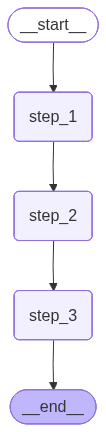

In [ ]:
graph

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).") 

#when any crash happens then we can resume from where bug happens rather than starting from scratch....
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)
